# Example: Monte Carlo Uncertainty Analysis

This notebook provides tutorial and code for running a model prediction uncertainty analysis via Monte Carlo simulations.

In [1]:
from garisom_tools import SperryModel
from garisom_tools.montecarlo import Sim, GarisomMonteCarloConfig

from datetime import datetime
import os
import pandas as pd

/Users/colinpannikkat/Documents/schoolwork/FEL/garisom/03_test_data/fremont-poplar-data/garisom-tools/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-09 14:59:36,862	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-09 14:59:37,267	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Setup model

In [2]:
# Absolute path directory links needed
model_dir = os.path.abspath("./garisom/02_program_code/")
param_directory = os.path.abspath("./DBG/")

In [3]:
# Set population (corresponds to line in parameters.csv file)
population = 1

In [4]:
# Function to get parameter and configuration files
def get_parameter_and_configuration_files(base_dir: str) -> tuple[str, pd.DataFrame]:
    return os.path.abspath(os.path.join(base_dir, "configuration.csv")), \
        pd.read_csv(os.path.join(base_dir, "parameters.csv"))

model_config, params = get_parameter_and_configuration_files(param_directory)

In [5]:
# Fetch the ground truth csv file for population
def get_ground_truth(population: int):
    ground_dir = "./files/ground"
    match population:
        case 1:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/ccr_hourly_data.csv"))
        case 2:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/jla_hourly_data.csv"))
        case 3:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/nrv_hourly_data.csv"))
        case 4:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/tsz_hourly_data.csv"))
        case _:
            raise Exception("Incorrect POP_NUM!")

    return ground
ground = get_ground_truth(population)

In [6]:
# Necessary start and date datetime instances for evaluation and optimization
start_date = datetime(2023, 7, 20)
end_date = datetime(2023, 8, 24)

In [7]:
# When running with the Monte Carlo Sim, it is necessary to pass in the following run_kwargs
run_kwargs = {
    'params': params,
    'config_file': model_config,
    'model_dir': model_dir,
    'population': population,
    'verbose': False
}

In [8]:
model = SperryModel()  # create model

## Setup sim

In [9]:
mc_config = {
    "space": {  # SpaceConfig using scipy mappings defined in montecarlo/config.py
        "i_baperga": ["truncnorm", [43.61021, 2.78188]],  # truncnorm through scipy has default bounds
        "i_height": ["truncnorm", [1.586, 0.09]],
        "i_leafWidth": ["truncnorm", [0.03439, 0.00089]],
        "i_cr": ["uniform", [10.9202863, 12.3192219]],
        "i_br": ["uniform", [2.51387228, 2.79282904]],
        "i_cs": ["uniform", [10.9202863, 12.3192219]],
        "i_bs": ["uniform", [2.51387228, 2.79282904]],
        "i_cl": ["uniform", [10.9202863, 12.3192219]],
        "i_bl": ["uniform", [2.51387228, 2.79282904]],
        "i_vmax25": ["truncnorm", [93.877834, 3.85]],
        "i_jmax25": ["truncnorm", [156.78, 6.43]]
    },
    "parameters": {  # Default parameters to override (typically with optimized parameter values)
        "i_leafAreaIndex": 1.5728953091043296,
        "i_rootBeta": 0.9778463022331645,
        "i_fieldCapFrac": 0.29950813581046,
        "i_fieldCapPercInit": 35.24273984214746,
        "i_kmaxTree": 243.43005827964475
    },
    "outputs": ["P-PD", "P-MD", "GW", "E-MD", "leaftemp"],  # Outputs for uncertainty prediction
    "num_worker": 4,
    "num_samples": 32,  # must be a power of 2 for sobol sampling
    "population": 1
}

In [10]:
mc_config = GarisomMonteCarloConfig.from_dict(mc_config)

In [11]:
sim = Sim(
    model=model,
    config=mc_config,
    run_kwargs=run_kwargs,
    engine='sobol',  # Quasi-random sampling, also supports 'latin' and 'halton'
    seed=42  # seed for reproducibility
)

In [12]:
# These are index columns that will not change between samples and therefore
# need to be excluded from any statistic calculations
index_columns = ['year', 'julian-day', 'standard-time', 'solar', 'rain', 'wind', 'T-air', 'T-soil', 'D-MD']

## Running sim

In [13]:
outputs = sim.run(
    mc_config.num_samples,
    workers=mc_config.num_worker,
    X=mc_config.parameters
)

100%|██████████| 32/32 [00:37<00:00,  1.16s/it]


In [ ]:
stats = sim.analyze(outputs, index_columns=index_columns)
# stats.save(dir)  # saves all statistics in directory

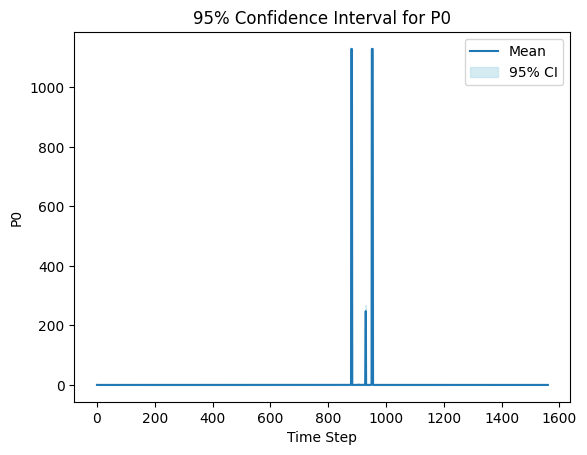

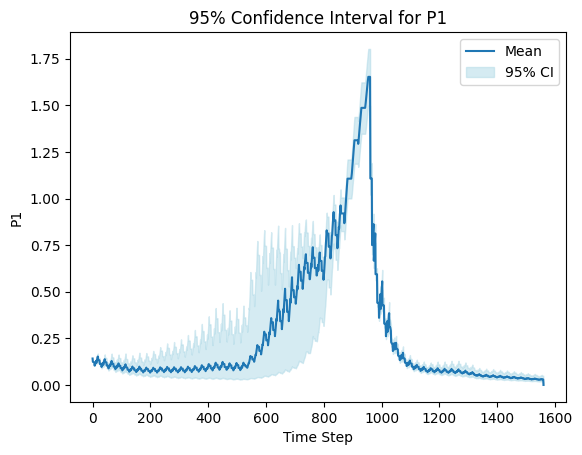

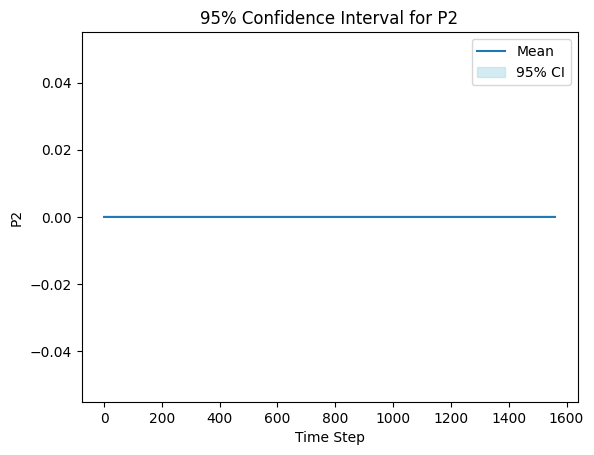

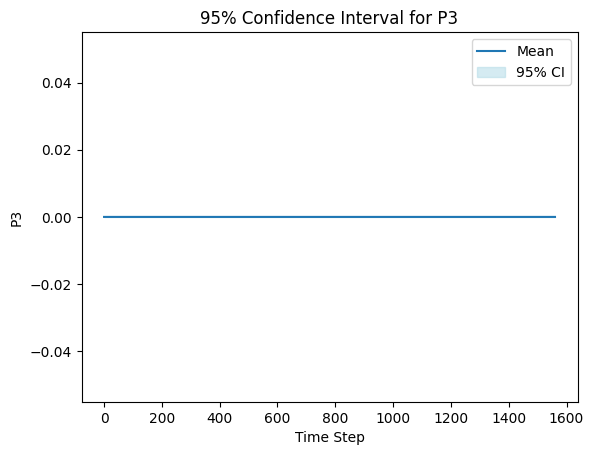

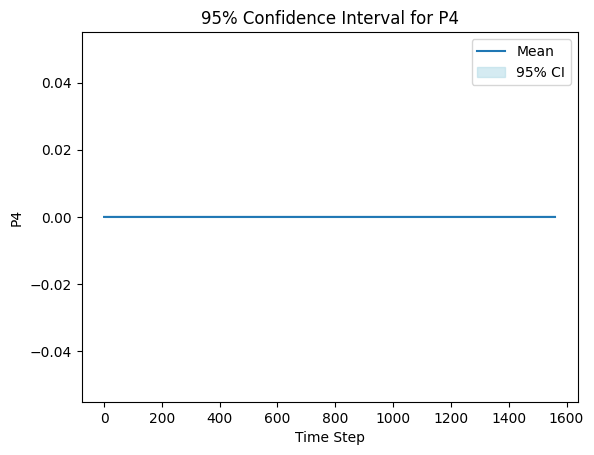

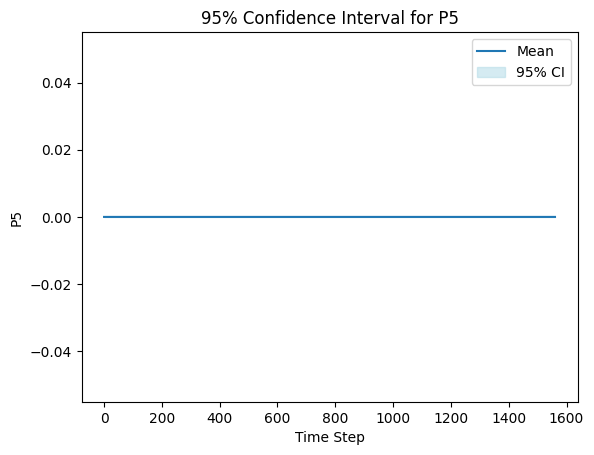

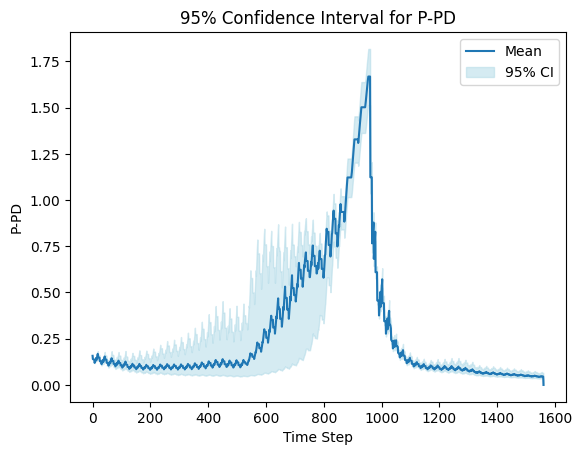

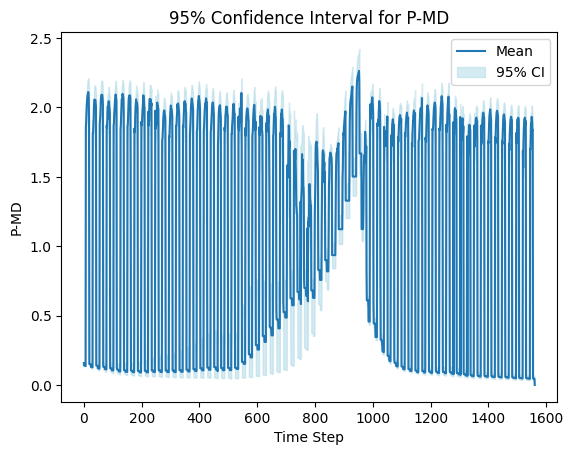

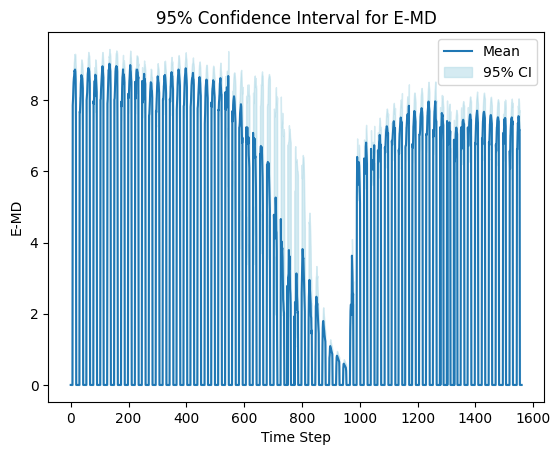

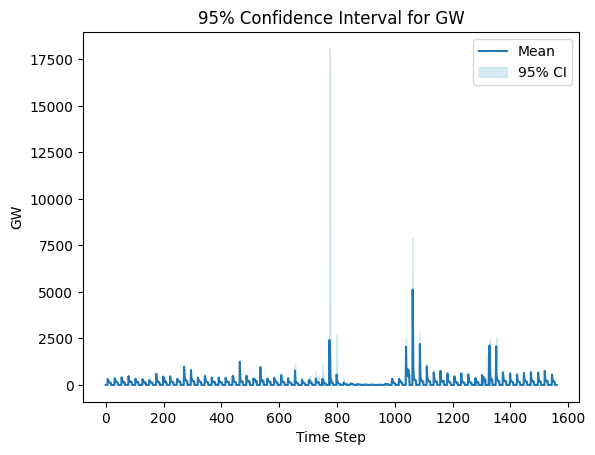

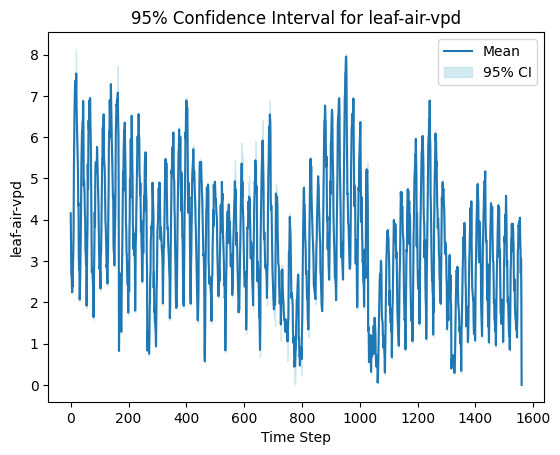

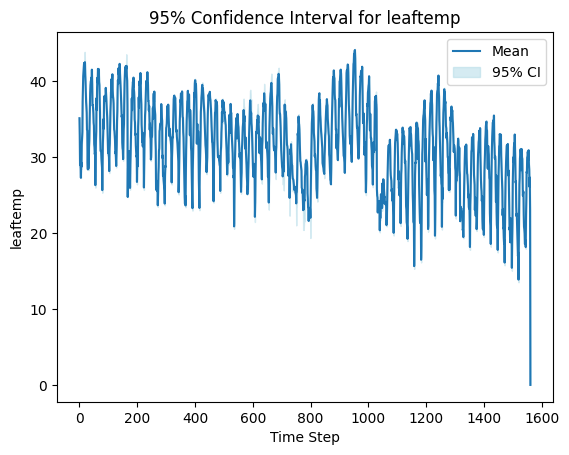

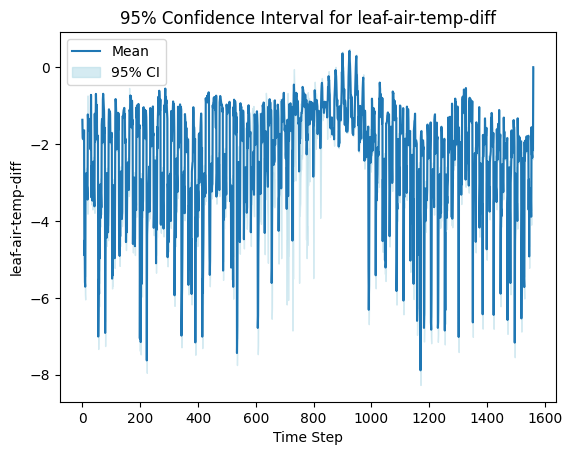

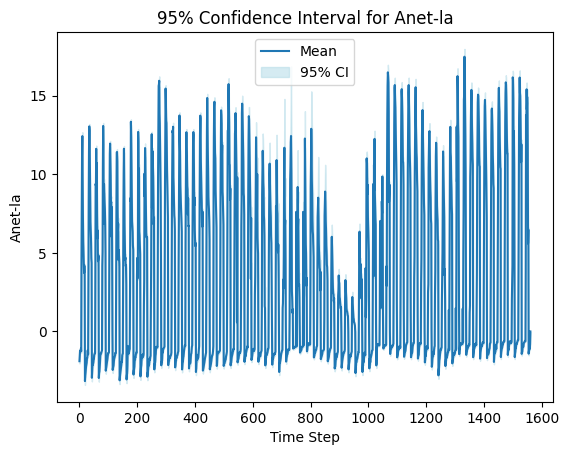

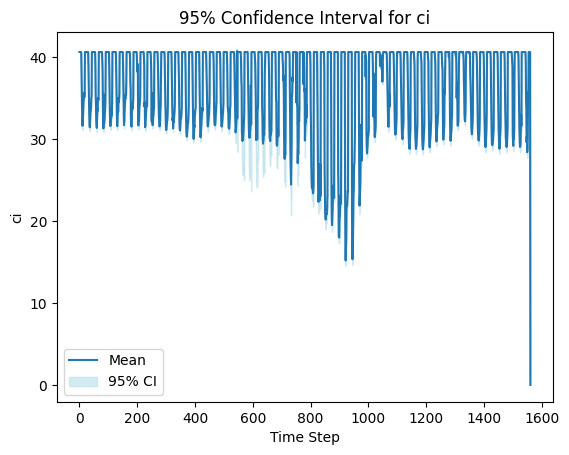

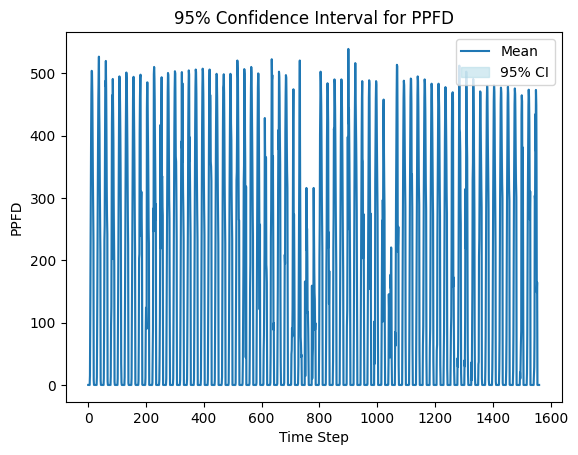

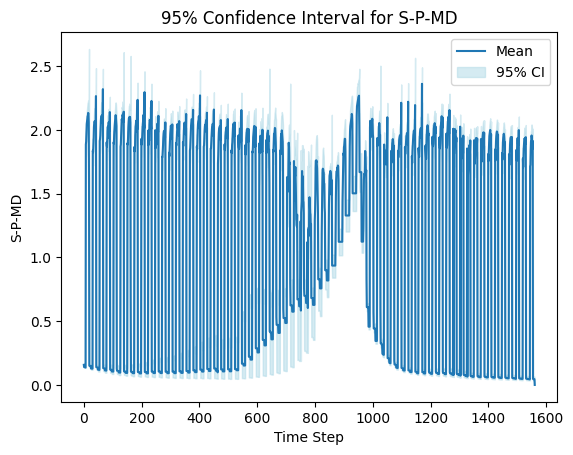

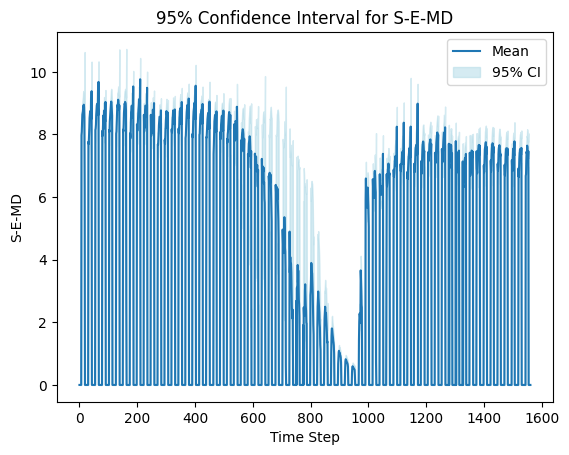

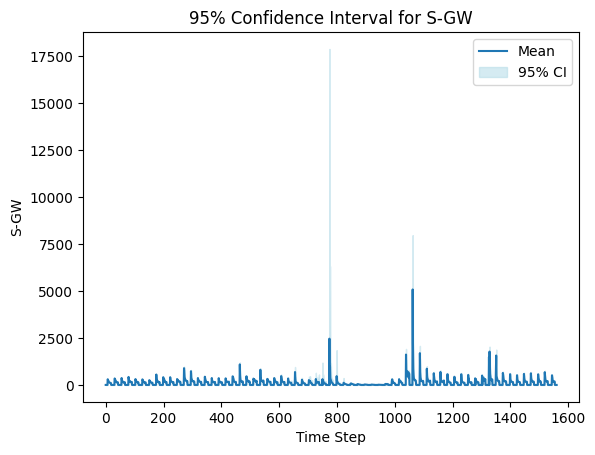

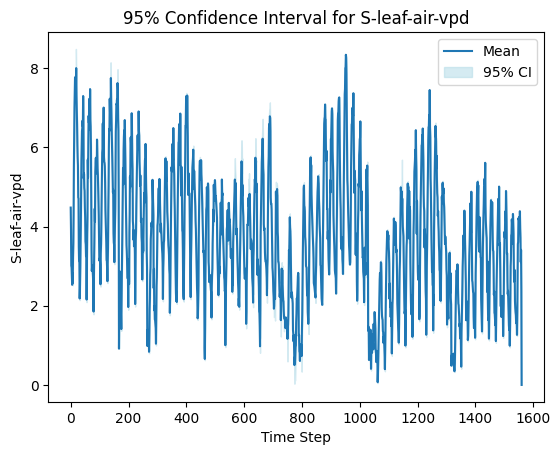

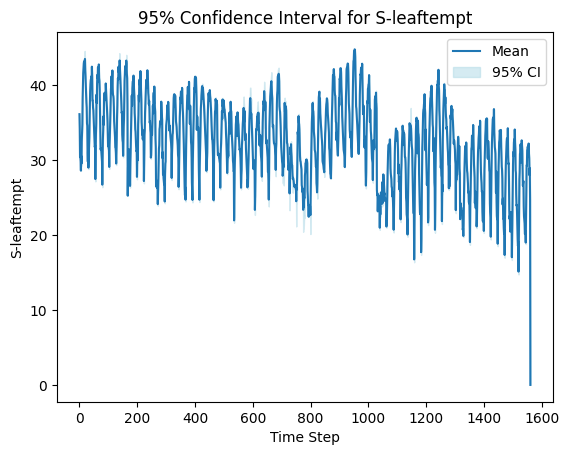

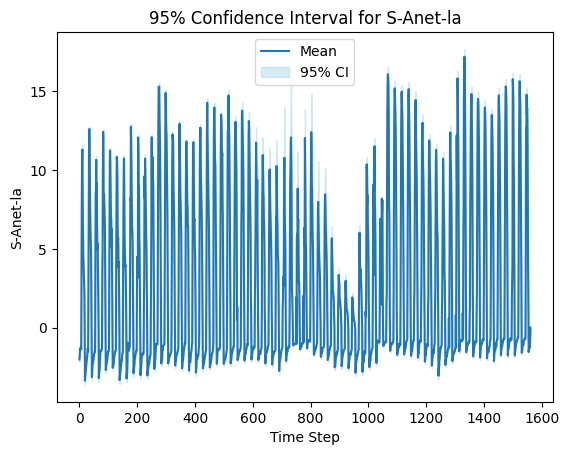

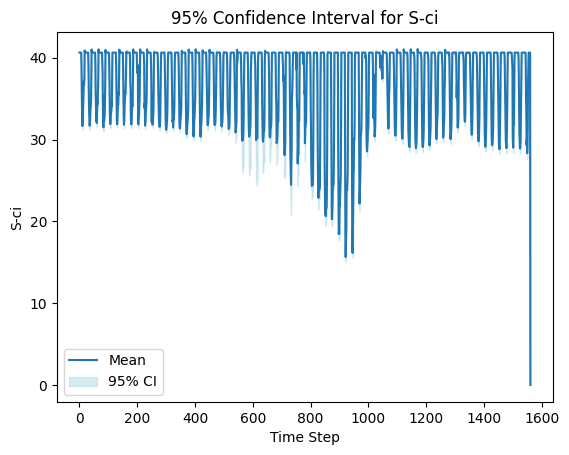

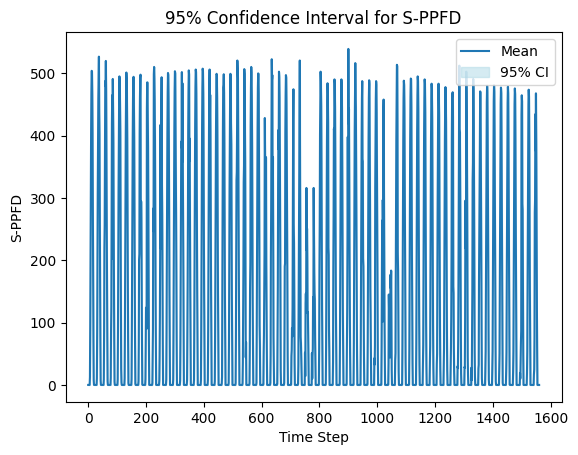

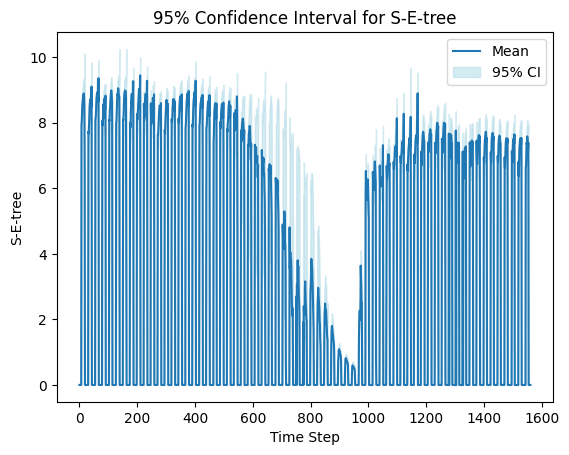

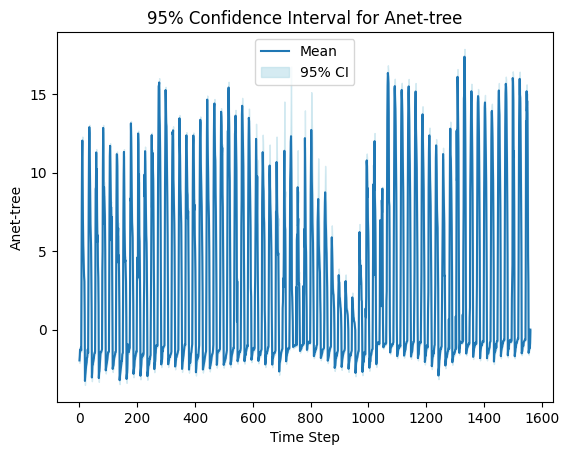

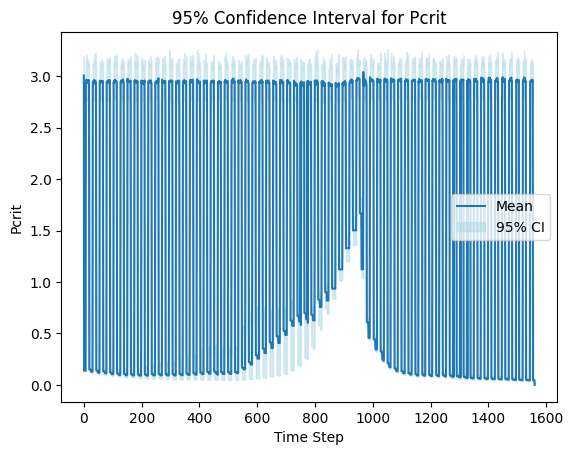

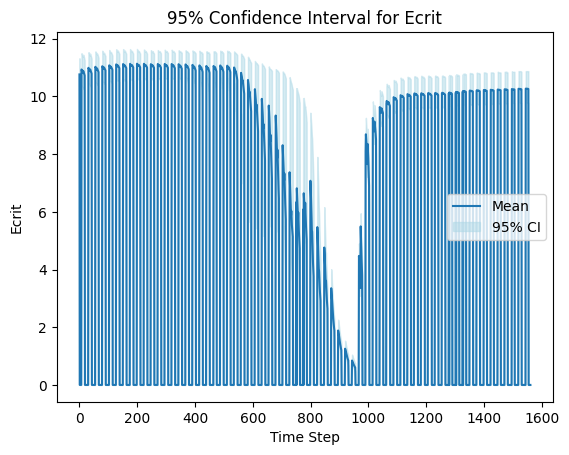

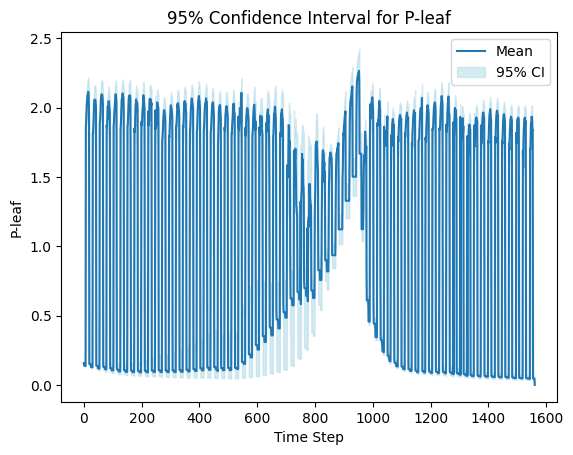

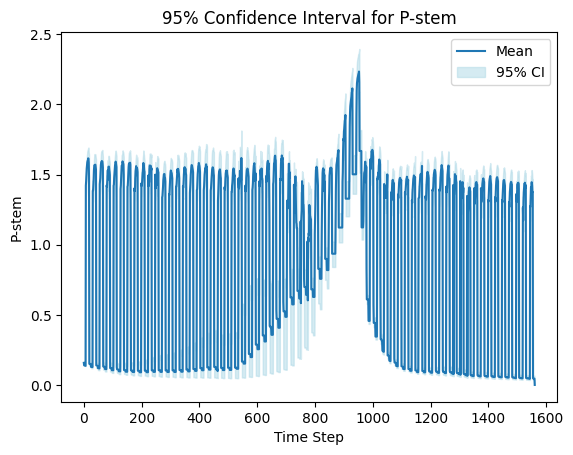

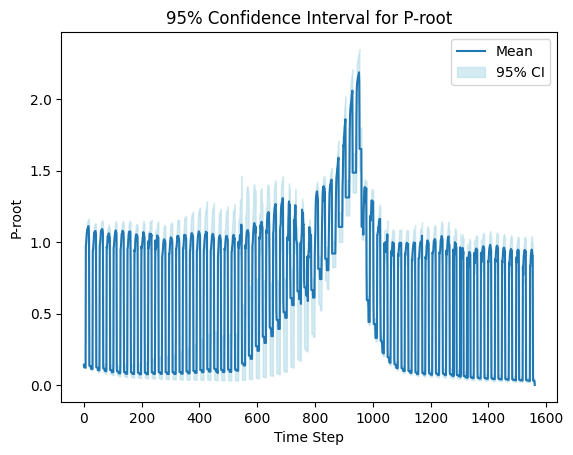

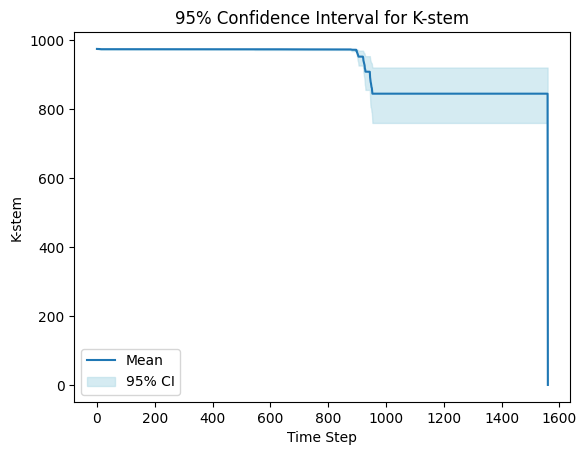

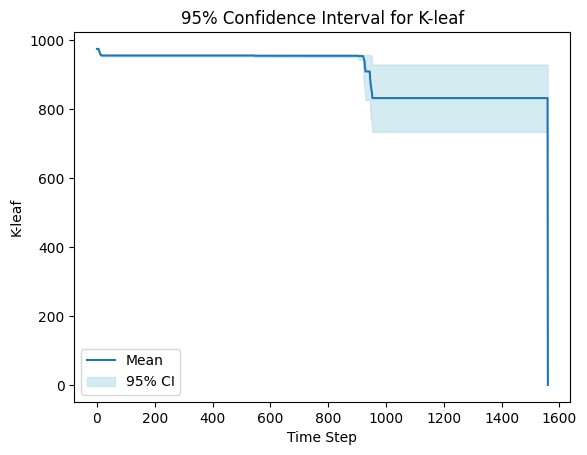

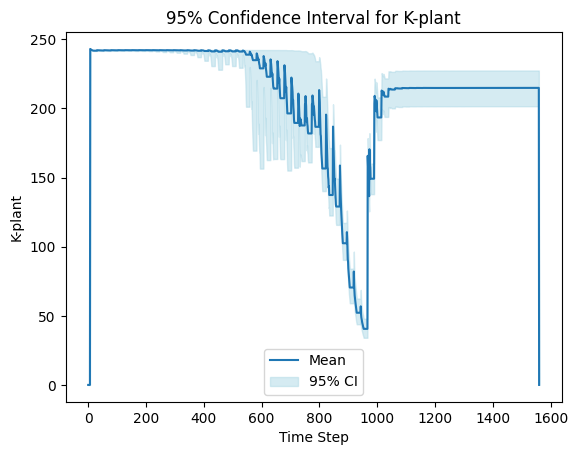

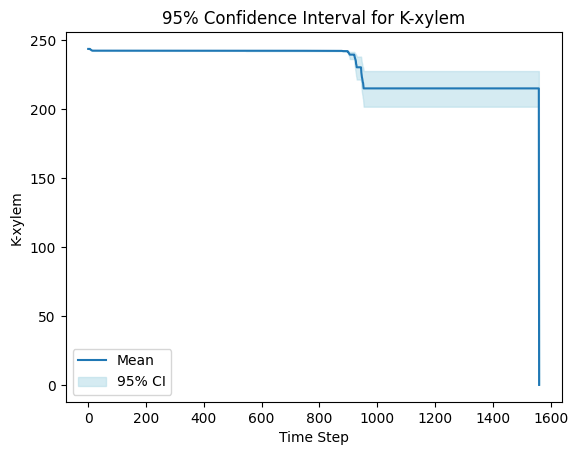

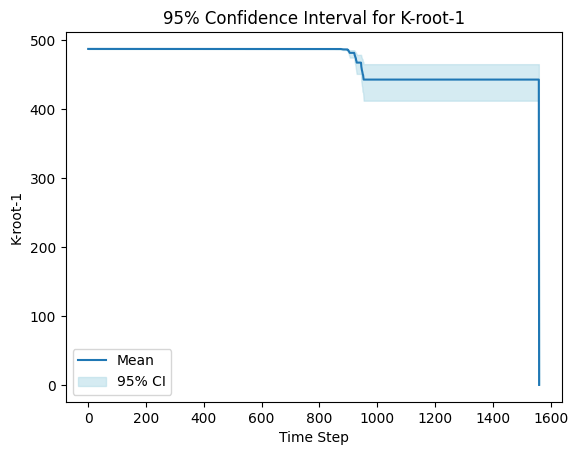

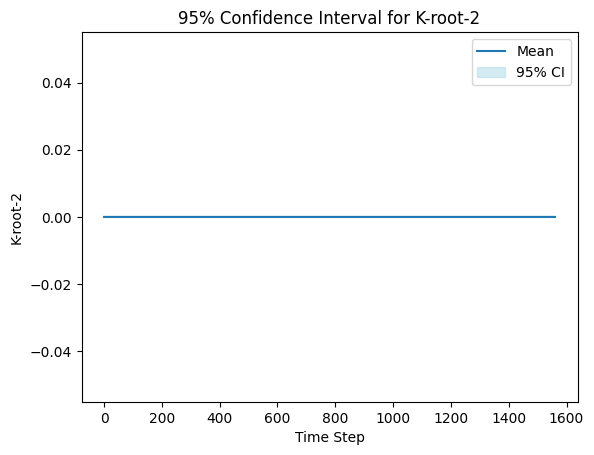

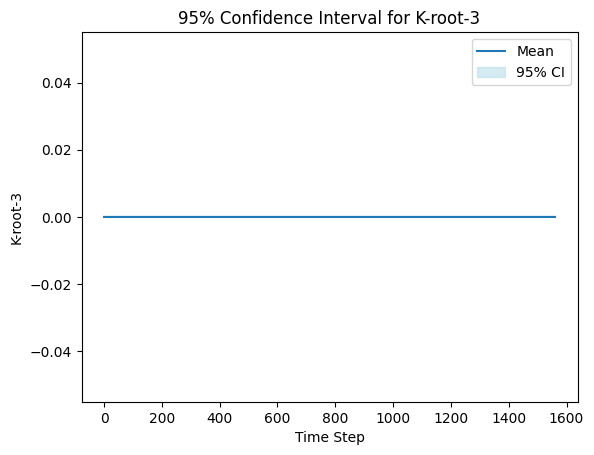

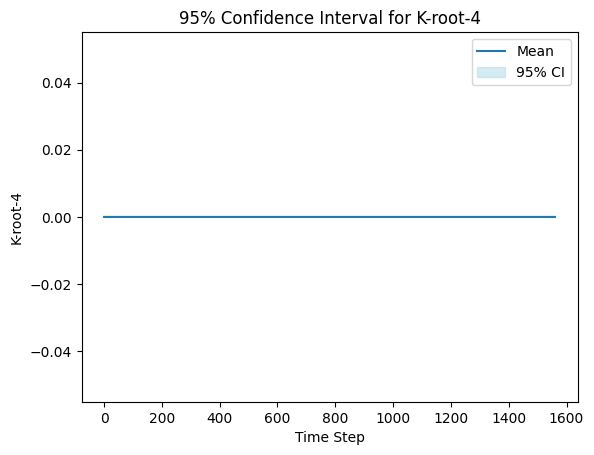

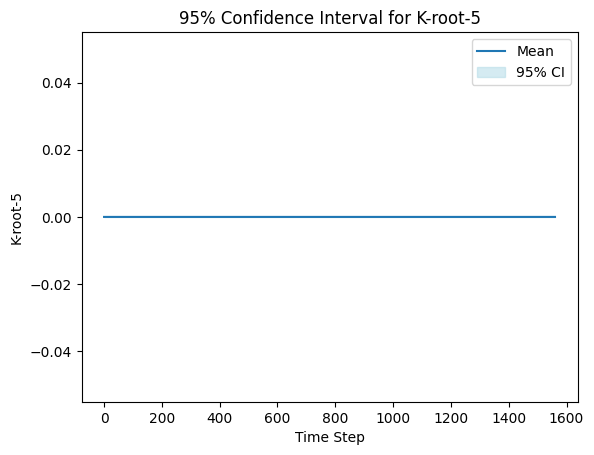

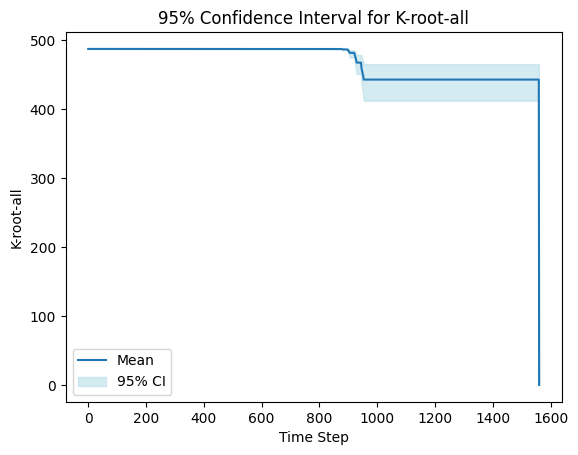

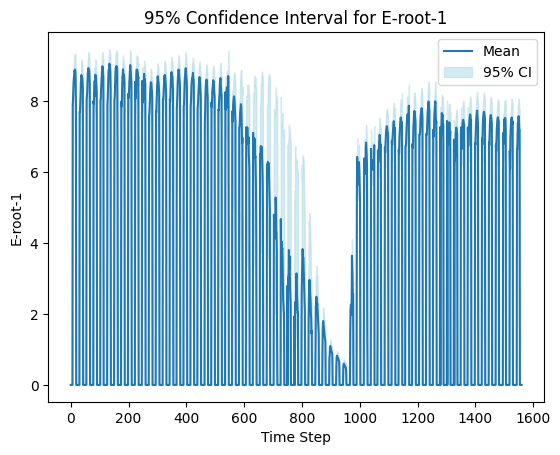

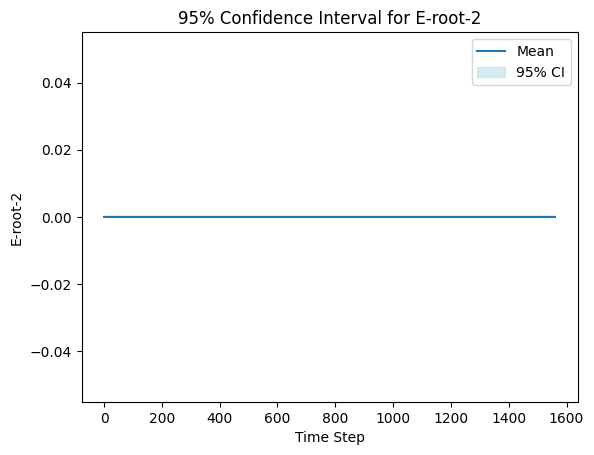

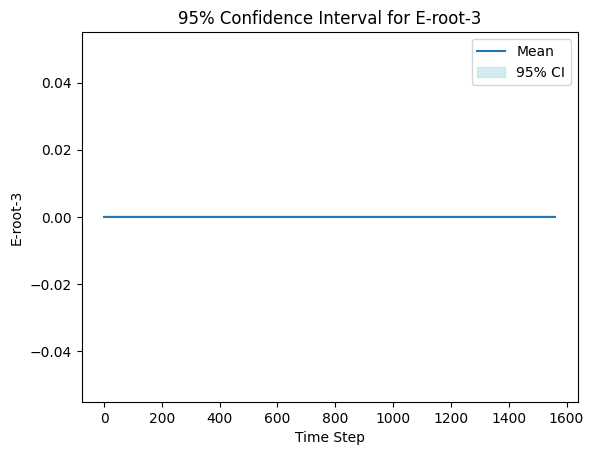

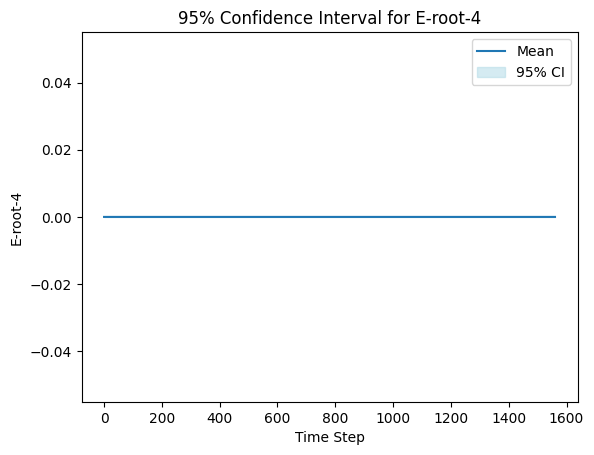

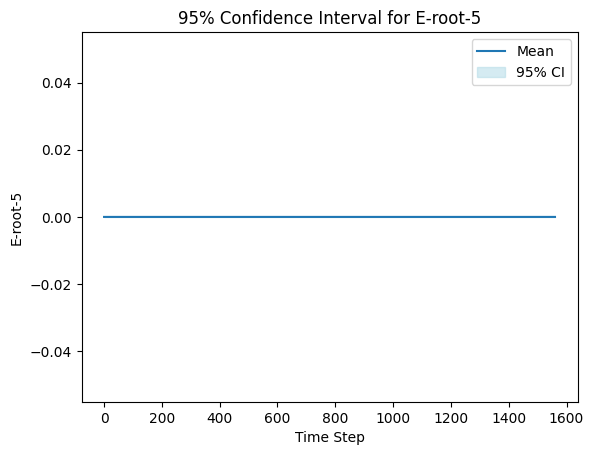

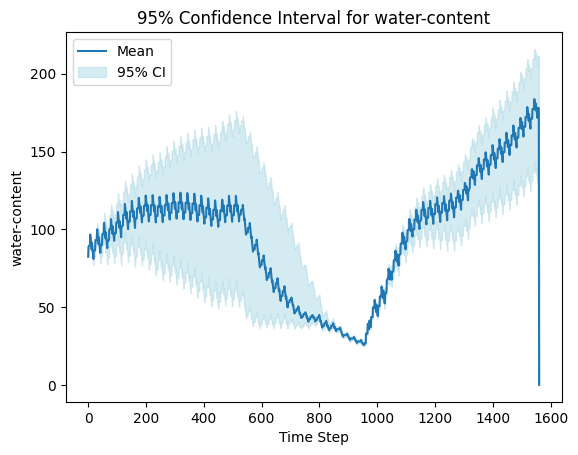

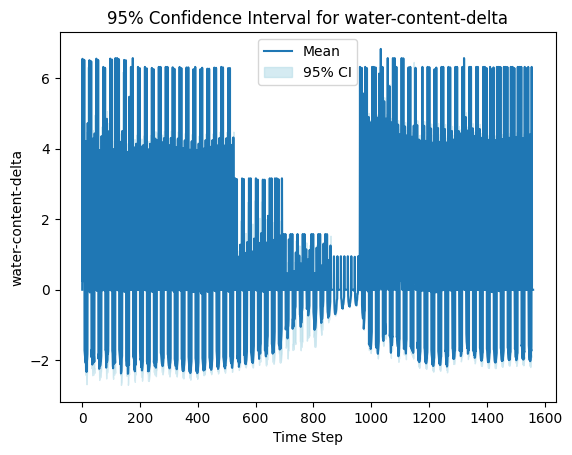

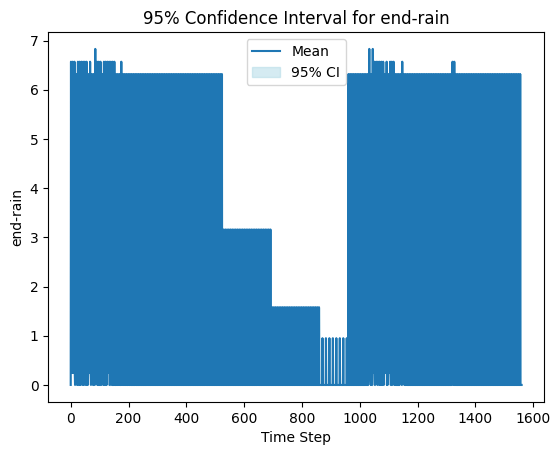

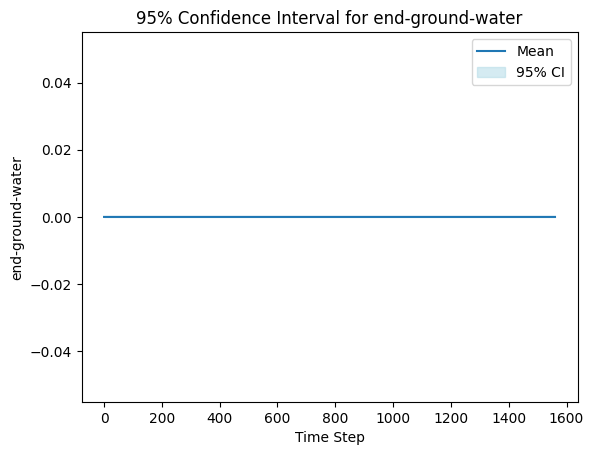

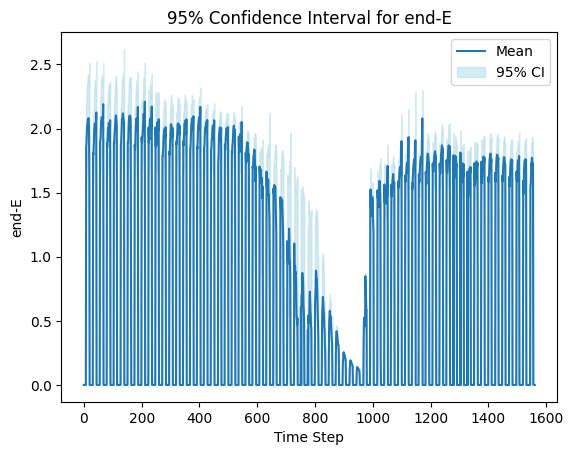

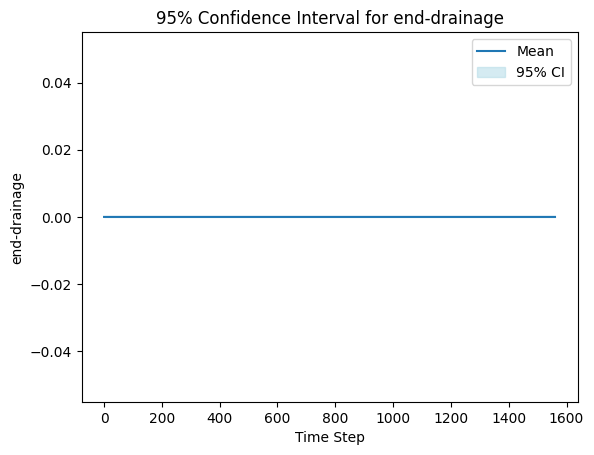

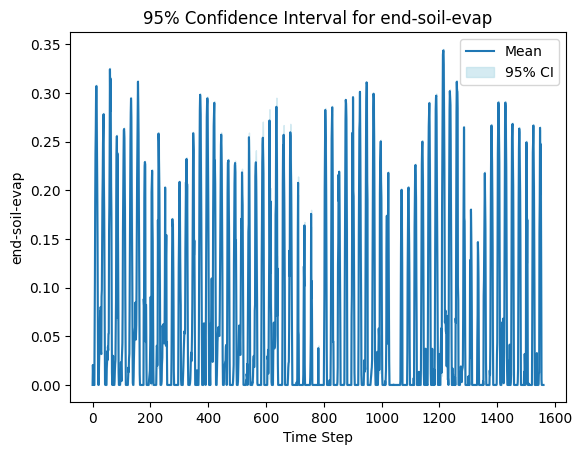

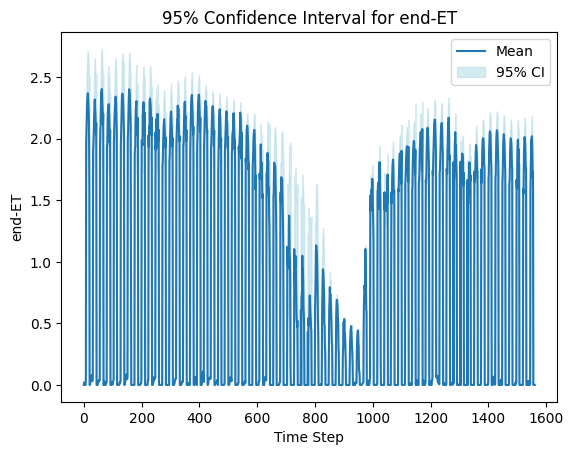

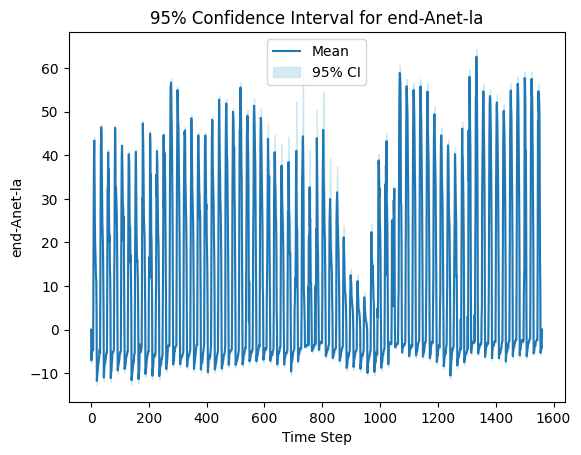

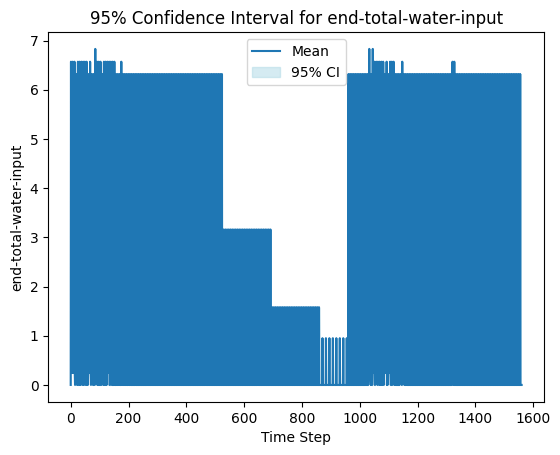

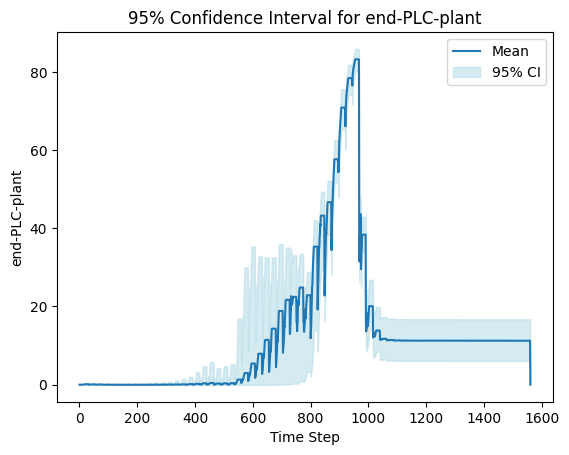

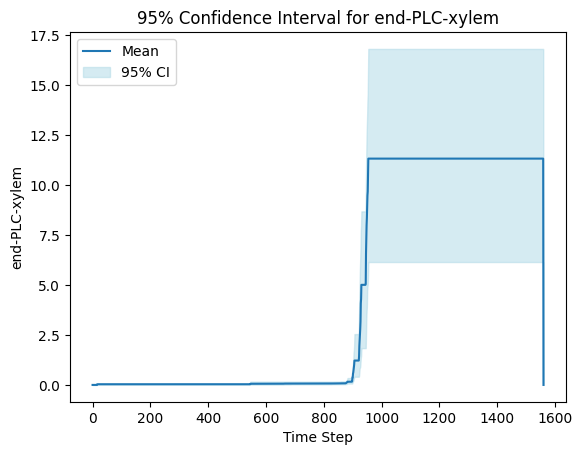

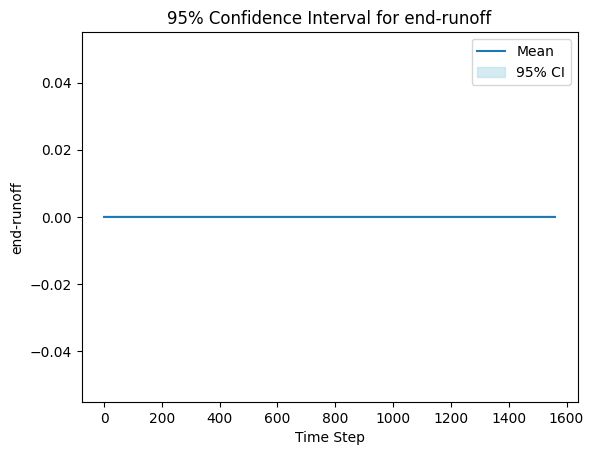

In [15]:
Sim.plot_ci(stats, index_columns=index_columns)